   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

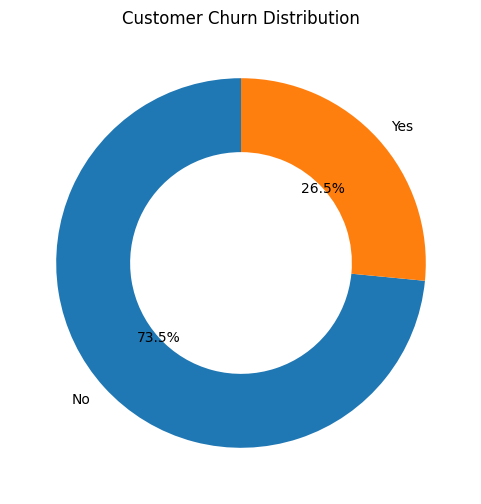

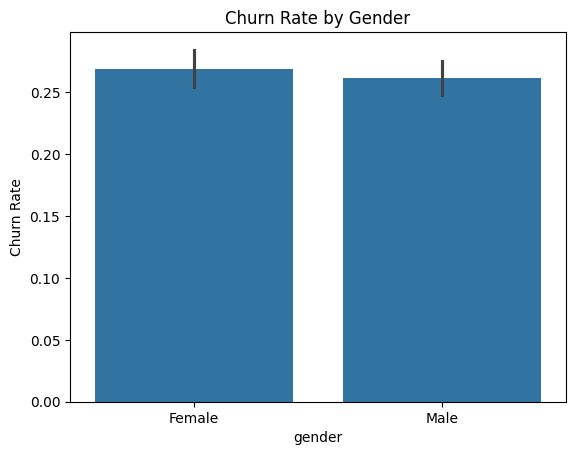

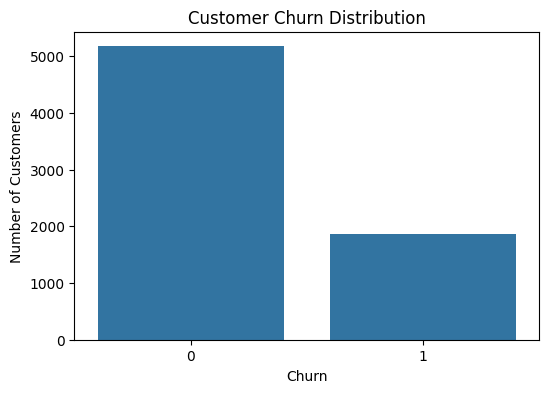

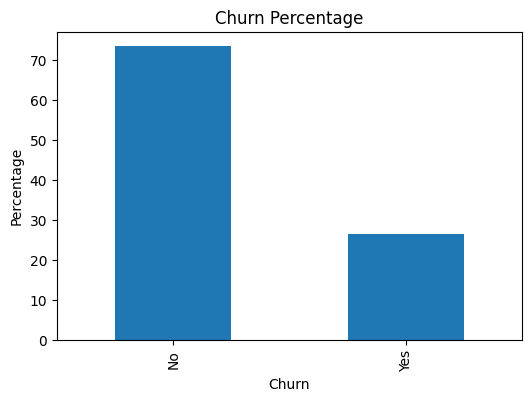

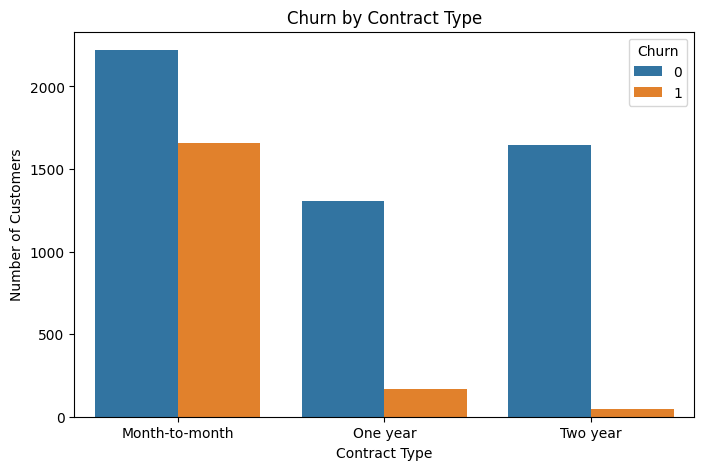

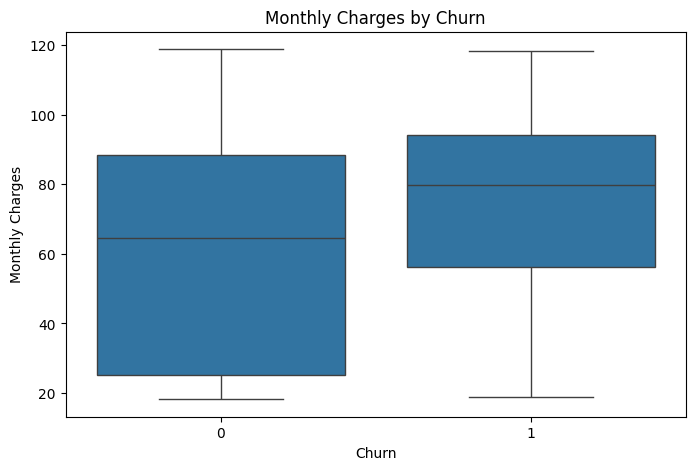

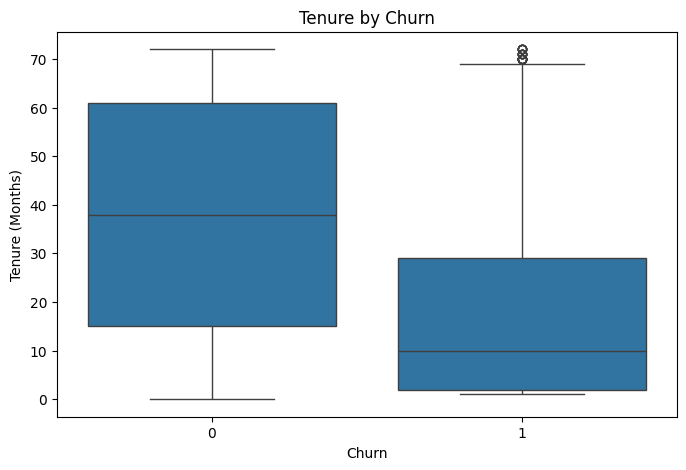


Categorical columns:
['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Training set: (5634, 18)
Test set: (1409, 18)


5-FOLD STRATIFIED CROSS-VALIDATION

Cross-Validation Results:
                     Accuracy  Precision  Recall      F1
Logistic Regression    0.8030     0.6549  0.5452  0.5944
Random Forest          0.7618     0.5357  0.7732  0.6327
Gradient Boosting      0.8046     0.6719  0.5157  0.5832
Decision Tree          0.7909     0.6322  0.5137  0.5647
XGBoost                0.8058     0.6708  0.5284  0.5908
Stacking               0.7473     0.5157  0.8060  0.6286


DETAILED CROSS-VALIDATION RESULTS

Logistic Regression
Accuracy : 0.8030
Precision: 0.6549
Recall   : 0.5452
F1 Score : 0.5944

Random Forest
Accuracy : 0

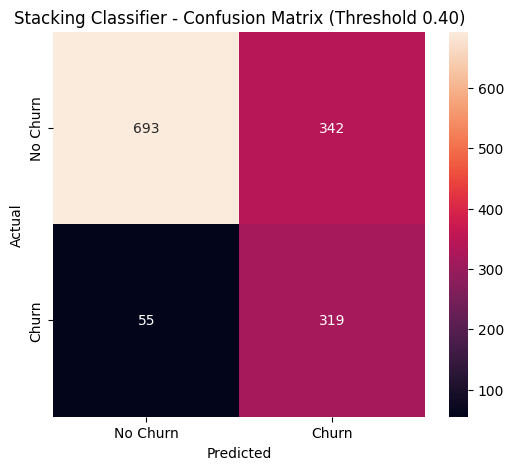

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("churndb.csv")

print(df.head())
print("\nShape:", df.shape)

df.info()

print("\nDescriptive Statistics:")
print(df.describe())


# ============================================================
# 2. DATA CLEANING
# ============================================================

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
print("\nMissing Values:")
print(df.isna().sum())


# ============================================================
# 3. CHURN DISTRIBUTION
# ============================================================

print("\nChurn Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


churn_percent = (
    df["Churn"]
    .value_counts(normalize=True) * 100
)

churn_counts = df["Churn"].value_counts()


# Convert target to 0/1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})


# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

# Churn distribution
plt.figure(figsize=(6, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Customer Churn Distribution")

plt.show()


# Churn rate by gender
sns.barplot(
    data=df,
    x="gender",
    y="Churn"
)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")

plt.show()


# Churn count
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


# Churn percentage
plt.figure(figsize=(6, 4))

churn_percent.plot(kind="bar")

plt.title("Churn Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage")

plt.show()


# Churn by contract
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()


# Monthly charges by churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


# Tenure by churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()


# ============================================================
# 5. FEATURES AND TARGET
# ============================================================

# Remove customerID, target, and gender
X = df.drop(
    columns=["customerID", "Churn", "gender"]
)

y = df["Churn"]


# Identify categorical columns
catCol = X.select_dtypes(
    include=["object"]
).columns.tolist()


# Identify numerical columns
numCol = X.select_dtypes(
    exclude=["object"]
).columns.tolist()


print("\nCategorical columns:")
print(catCol)

print("\nNumerical columns:")
print(numCol)


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)


# ============================================================
# 7. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numCol
    ),
    (
        "cat",
        categorical_pipeline,
        catCol
    )
])


# ============================================================
# 8. DEFINE BASE MODELS
# ============================================================

# -------------------------
# Logistic Regression
# -------------------------

logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])


# -------------------------
# Random Forest
# -------------------------

random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])


# -------------------------
# Gradient Boosting
# -------------------------

gradient_boosting_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])


# -------------------------
# Decision Tree
# -------------------------

decision_tree_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        )
    )
])


# -------------------------
# XGBoost
# -------------------------

xgb_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])


# ============================================================
# 9. STACKING CLASSIFIER
# ============================================================

stacking_model = StackingClassifier(
    estimators=[
        (
            "logistic",
            logistic_model
        ),
        (
            "gradient_boosting",
            gradient_boosting_model
        ),
        (
            "xgboost",
            xgb_model
        )
    ],

    final_estimator=RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=1,
        n_jobs=-1
    ),

    cv=5,

    stack_method="predict_proba",

    n_jobs=-1
)


# ============================================================
# 10. CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
    "Decision Tree": decision_tree_model,
    "XGBoost": xgb_model,
    "Stacking": stacking_model
}


scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}


results = {}


print("\n")
print("=" * 75)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 75)


for name, model in models.items():

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = {
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean()
    }


# Convert results to DataFrame
results_df = pd.DataFrame(results).T


print("\nCross-Validation Results:")
print(results_df.round(4))


# ============================================================
# 11. DETAILED CROSS-VALIDATION RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("DETAILED CROSS-VALIDATION RESULTS")
print("=" * 75)


for model_name, row in results_df.iterrows():

    print(f"\n{model_name}")

    print(
        f"Accuracy : {row['Accuracy']:.4f}"
    )

    print(
        f"Precision: {row['Precision']:.4f}"
    )

    print(
        f"Recall   : {row['Recall']:.4f}"
    )

    print(
        f"F1 Score : {row['F1']:.4f}"
    )


# ============================================================
# 12. FINAL STACKING MODEL
# ============================================================

# Train the final stacking model
# on the complete training set

final_model = stacking_model

final_model.fit(
    X_train,
    y_train
)


# ============================================================
# 13. GET CHURN PROBABILITIES
# ============================================================

stacking_prob = final_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 14. TEST DIFFERENT THRESHOLDS
# ============================================================

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]


print("\n")
print("=" * 75)
print("THRESHOLD COMPARISON - STACKING")
print("=" * 75)


for threshold in thresholds:

    stacking_threshold_pred = (
        stacking_prob >= threshold
    ).astype(int)

    report = classification_report(
        y_test,
        stacking_threshold_pred,
        output_dict=True
    )

    print(
        f"\nThreshold: {threshold:.2f}"
    )

    print(
        f"Accuracy: "
        f"{accuracy_score(y_test, stacking_threshold_pred):.4f}"
    )

    print(
        f"Churn Recall: "
        f"{report['1']['recall']:.4f}"
    )

    print(
        f"Churn Precision: "
        f"{report['1']['precision']:.4f}"
    )

    print(
        f"Churn F1: "
        f"{report['1']['f1-score']:.4f}"
    )


# ============================================================
# 15. FINAL THRESHOLD = 0.40
# ============================================================

threshold = 0.40

stacking_threshold_pred = (
    stacking_prob >= threshold
).astype(int)


# ============================================================
# 16. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("FINAL STACKING RESULTS - THRESHOLD 0.40")
print("=" * 75)


print(
    "\nAccuracy:",
    accuracy_score(
        y_test,
        stacking_threshold_pred
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        stacking_threshold_pred
    )
)


print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test,
    stacking_threshold_pred
)

print(cm)


# ============================================================
# 17. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(
    "Stacking Classifier - Confusion Matrix (Threshold 0.40)"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

train_pred = random_forest_model.predict(X_train)
test_pred = random_forest_model.predict(X_test)

print("TRAINING RESULTS")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("Recall:", recall_score(y_train, train_pred))

print("\nTESTING RESULTS")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, test_pred))

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, test_pred))



TRAINING RESULTS
Accuracy: 0.7925097621583245
Recall: 0.8421404682274247

TESTING RESULTS
Accuracy: 0.7572746628814763
Recall: 0.7754010695187166

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


CONFUSION MATRIX
[[777 258]
 [ 84 290]]


In [53]:
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]
threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    threshold_pred = (rf_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, threshold_pred),
        "Precision": precision_score(y_test, threshold_pred, zero_division=0),
        "Recall": recall_score(y_test, threshold_pred, zero_division=0),
        "F1 Score": f1_score(y_test, threshold_pred, zero_division=0)
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison.round(3)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.652,0.427,0.901,0.579
1,0.4,0.697,0.461,0.845,0.597
2,0.5,0.745,0.513,0.773,0.617
3,0.6,0.779,0.570,0.682,0.621
4,0.7,0.795,0.638,0.532,0.580


In [54]:
print(df.dtypes)
for column in catCol:
    print("\n", column)
    print(df[column].unique())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Ye

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
logistic_cv = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

print("Logistic Regression")
print("Mean accuracy:", logistic_cv["test_accuracy"].mean())
print("Mean recall:", logistic_cv["test_recall"].mean())
print("Mean F1:", logistic_cv["test_f1"].mean())
print("Mean ROC-AUC:", logistic_cv["test_roc_auc"].mean())


In [57]:
from sklearn.ensemble import VotingClassifier

# Voting Classifier

voting_model = VotingClassifier(
    estimators=[
        ("logistic", logistic_model),
        ("random_forest", random_forest_model),
        ("gradient_boosting", gradient_boosting_model),
        ("decision_tree_model", decision_tree_model),
        ("xgb_model", xgb_model)

        
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)

print("Voting Classifier Results")
print("Accuracy:", accuracy_score(y_test, voting_pred))

print("\nClassification Report:")
print(classification_report(y_test, voting_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, voting_pred))

Voting Classifier Results
Accuracy: 0.8048261178140526

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Confusion Matrix:
[[911 124]
 [151 223]]


In [63]:
# Stacking Classifier
# Random Forest is the final blending layer

stacking_model = StackingClassifier(
    estimators=[
        ("logistic", logistic_model),
        ("gradient_boosting", gradient_boosting_model),
        ("xgboost", xgb_model)
    ],
    final_estimator=RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=1,
        n_jobs=-1
    ),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

stacking_pred = stacking_model.predict(X_test)

print("Stacking Classifier Results")
print("Accuracy:", accuracy_score(y_test, stacking_pred))

print("\nClassification Report:")
print(classification_report(y_test, stacking_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, stacking_pred))

Stacking Classifier Results
Accuracy: 0.7409510290986515

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.76      1409


Confusion Matrix:
[[740 295]
 [ 70 304]]


In [64]:
# Check for overfitting

stacking_train_pred = stacking_model.predict(X_train)
stacking_test_pred = stacking_model.predict(X_test)

train_accuracy = accuracy_score(y_train, stacking_train_pred)
test_accuracy = accuracy_score(y_test, stacking_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("Difference:", train_accuracy - test_accuracy)

Training Accuracy: 0.7616258430954916
Test Accuracy: 0.7409510290986515
Difference: 0.020674813996840125


In [66]:
# Test different thresholds for Stacking

stacking_prob = stacking_model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

for threshold in thresholds:

    stacking_threshold_pred = (
        stacking_prob >= threshold
    ).astype(int)

    report = classification_report(
        y_test,
        stacking_threshold_pred,
        output_dict=True
    )

    print(f"\nThreshold: {threshold}")
    print("Accuracy:", accuracy_score(y_test, stacking_threshold_pred))
    print("Churn Recall:", report["1"]["recall"])
    print("Churn Precision:", report["1"]["precision"])
    print("Churn F1:", report["1"]["f1-score"])

    # Confusion matrix at threshold 0.4

threshold = 0.4

stacking_threshold_pred = (
    stacking_prob >= threshold
).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, stacking_threshold_pred))

print("\nClassification Report:")
print(classification_report(y_test, stacking_threshold_pred))


Threshold: 0.3
Accuracy: 0.6713981547196594
Churn Recall: 0.9117647058823529
Churn Precision: 0.44228274967574577
Churn F1: 0.5956331877729257

Threshold: 0.35
Accuracy: 0.694819020581973
Churn Recall: 0.8636363636363636
Churn Precision: 0.4601139601139601
Churn F1: 0.6003717472118959

Threshold: 0.4
Accuracy: 0.7182398864442867
Churn Recall: 0.8529411764705882
Churn Precision: 0.4826021180030257
Churn F1: 0.6164251207729469

Threshold: 0.45
Accuracy: 0.7374024130589071
Churn Recall: 0.8288770053475936
Churn Precision: 0.5032467532467533
Churn F1: 0.6262626262626263

Threshold: 0.5
Accuracy: 0.7409510290986515
Churn Recall: 0.8128342245989305
Churn Precision: 0.5075125208681135
Churn F1: 0.6248715313463515
Confusion Matrix:
[[693 342]
 [ 55 319]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1035
           1       0.48      0.85      0.62       374

    accuracy                           0.72      1409
